In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
#print(df.describe())
#print(df.info())
#print(df.isnull().sum())

Dużo wartości zerowych dla kolumny PURPOSE* - brak danych o celu jazdy

#Jaka jest srednia długosć jazdy
#Jaka jest srednia ilosc jazd w dzien, noc, tydzień, miesiąc
#Jaka jeest srednia długosć jazdy ogolnie i z podziałem na kategorie (purpose)
#Skąd są najczęciej odjazdy i dokąd 
#Czy ilosc kursow jest powiązana z jakims swiętem?
#Jak godziny szczytu mają wpływ na prędkosc podróży

## Kiedy jest największe natężenie ruchu w ciągu dnia?

In [17]:
data= pd.read_csv("D:/PROJEKTY/Uber/uber.csv")
data.head(10)

#dataframe
df = pd.DataFrame(data)

# kolumny na datatime
df["START_DATE*"] = pd.to_datetime(df["START_DATE*"], errors="coerce")
df["END_DATE*"] = pd.to_datetime(df["END_DATE*"], errors="coerce")

# Rozdzielenie 
df["START_DATE_ONLY"] = df["START_DATE*"].dt.date
df["START_TIME_ONLY"] = df["START_DATE*"].dt.time
df["END_DATE_ONLY"] = df["END_DATE*"].dt.date
df["END_TIME_ONLY"] = df["END_DATE*"].dt.time

print(df)

             START_DATE*           END_DATE* CATEGORY*            START*  \
0    2016-01-01 21:11:00 2016-01-01 21:17:00  Business       Fort Pierce   
1    2016-01-02 01:25:00 2016-01-02 01:37:00  Business       Fort Pierce   
2    2016-01-02 20:25:00 2016-01-02 20:38:00  Business       Fort Pierce   
3    2016-01-05 17:31:00 2016-01-05 17:45:00  Business       Fort Pierce   
4    2016-01-06 14:42:00 2016-01-06 15:49:00  Business       Fort Pierce   
...                  ...                 ...       ...               ...   
1151 2016-12-31 13:24:00 2016-12-31 13:42:00  Business           Kar?chi   
1152 2016-12-31 15:03:00 2016-12-31 15:38:00  Business  Unknown Location   
1153 2016-12-31 21:32:00 2016-12-31 21:50:00  Business        Katunayake   
1154 2016-12-31 22:08:00 2016-12-31 23:51:00  Business           Gampaha   
1155                 NaT                 NaT       NaN               NaN   

                 STOP*   MILES*         PURPOSE* START_DATE_ONLY  \
0          Fort Pie

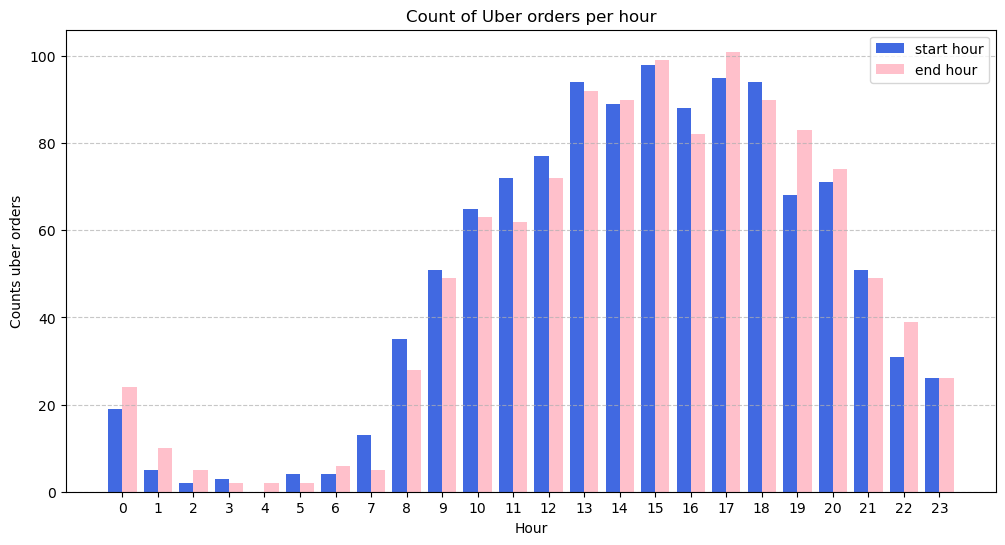

In [19]:
#wizualizacja 
df["HOUR"] = df["START_TIME_ONLY"].apply(lambda x: x.hour)
hourly_orders = df["HOUR"].value_counts().sort_index()



end_time = df["END_TIME_ONLY"].apply(lambda x: x.hour)
end_hourly_orders = end_time.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(hourly_orders.index -0.2, hourly_orders.values, width= 0.4, color="royalblue", label= "start hour")
plt.bar(end_hourly_orders.index +0.2, end_hourly_orders.values, width = 0.4, color="pink", label = "end hour")
plt.legend()
plt.xlabel("Hour")
plt.ylabel("Counts uber orders")
plt.title("Count of Uber orders per hour")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

Największe natężenie ruchu występuje w godzinach szczytu. Natomiast najniższe natężenie
ruchu następuje w godzinach nocnych. 

## Jaka jest średnia długość jazdy? 


In [23]:
df["DURATION"] = df["END_DATE*"] - df["START_DATE*"]
df["DURATION"].mean()
mean = str(df['DURATION'].mean()).replace("0 days ", "").split(".")[0]
print('Mean: ', mean)

Mean:  00:23:14


## Jaka jest średnia ilość jazd w dzień, noc, tydzień, miesiąc 

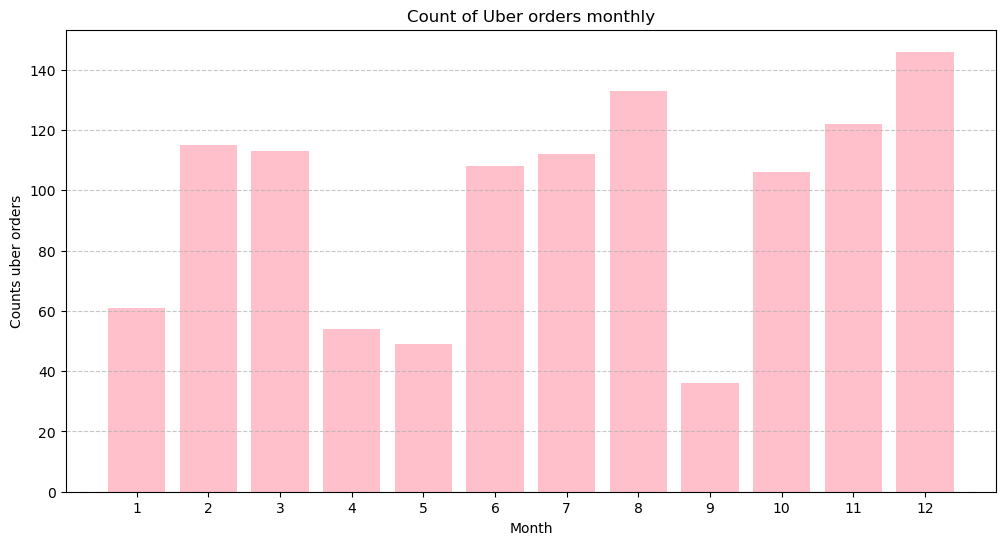

In [26]:
#Noc przyjmujemy jako od 18 do 6 rano
#Tydzień rozpoczynamy od 01.01.2016
months_counts = df["START_DATE_ONLY"].apply(lambda x: x.month)
months_orders = months_counts.value_counts().sort_index()
months_orders

plt.figure(figsize=(12, 6))
plt.bar(months_orders.index, months_orders.values, color="pink")
plt.xlabel("Month")
plt.ylabel("Counts uber orders")
plt.title("Count of Uber orders monthly")
plt.xticks(range(1, 13))
plt.grid(axis="y", linestyle="--", alpha=0.7)

Obserwujemy drastyczny spadek zamówień we wrześniu w okresie powakacyjnym. Wysokie wartości są widoczne w miesiącach letnich, przedwiosennych oraz przedświątecznych. Wpływ na wyżej pokazane dane może mieć pogoda panująca w danym miejscu. Miesiące luty, marzec, październik, listopad, grudzień odznaczają się niskimi temperaturami, natomiast czerwiec, lipiec, sierpień wysokimi. Tak skrajne temperatury są uciążliwe dla większości populacji, natomiast miesiące kwiecień, maj i wrzesień mają temperatury umiarkowane, co zachęca do spaceru i skorzystania z optymalnej pogody, co przekłada się na mniejsze ilości zamówień. 

## Jaka jeest średnia długość jazdy ogólnie i z podziałem na kategorie (purpose) 

In [30]:
df['DURATION'].mean()

#z podziałem na kategorie 
print(df['PURPOSE*'].value_counts(), '\n')
unique_purposes = df['PURPOSE*'].unique()

for i in unique_purposes:
    global selected, mean_duration
    selected = df[df['PURPOSE*'] == i]
    mean_duration = selected['DURATION'].mean()
    mean_duration = str(mean_duration).replace("0 days ", "").split(".")[0]
    print('Category:', i, '\n Duration', mean_duration, '\n')


PURPOSE*
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64 

Category: Meal/Entertain 
 Duration 00:16:07 

Category: nan 
 Duration NaT 

Category: Errand/Supplies 
 Duration 00:12:58 

Category: Meeting 
 Duration 00:29:44 

Category: Customer Visit 
 Duration 00:33:24 

Category: Temporary Site 
 Duration 00:25:51 

Category: Between Offices 
 Duration 00:25:30 

Category: Charity ($) 
 Duration 00:27:00 

Category: Commute 
 Duration 03:05:00 

Category: Moving 
 Duration 00:15:00 

Category: Airport/Travel 
 Duration 00:26:00 



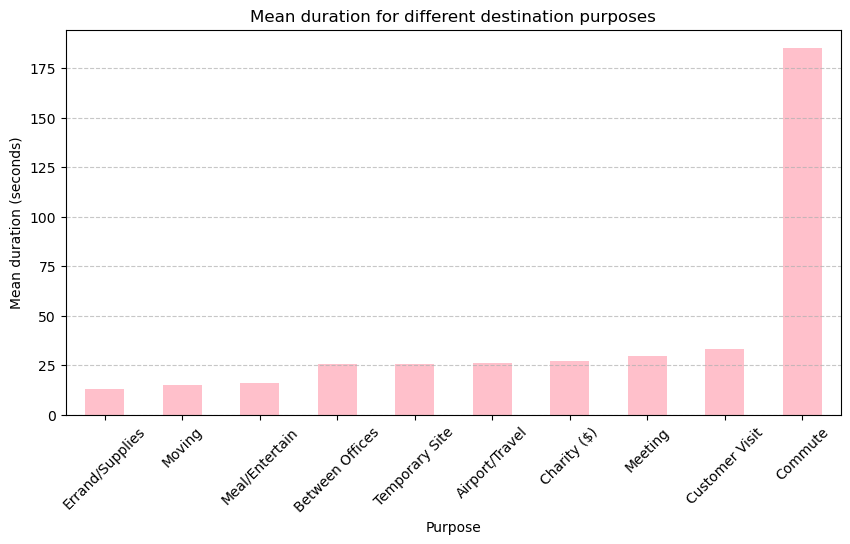

In [32]:
# DRUGI SPOSÓB
mean_durations = df.groupby("PURPOSE*")["DURATION"].mean()

# Usuwamy "0 days" i przekształcamy timedelta na sekundy
mean_durations_clean = mean_durations.dt.total_seconds() / 60  # Konwersja na minuty

# Tworzymy wykres
plt.figure(figsize=(10, 5))
mean_durations_clean.sort_values().plot(kind="bar", color="pink")

# Opisy wykresu
plt.xlabel("Purpose")
plt.ylabel("Mean duration (seconds)")
plt.title("Mean duration for different destination purposes")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Wyświetlenie wykresu
plt.show()

Commute to wartość skrajna (tylko jeden wiersz w tabeli miał tą kategorię), a więc może być to nieobiektywne, tym bardziej, że trwał on trzy godziny, czyli około 6 razy dłużej niż poprzedni. Poniżej wykonano wykres bez uwzględniania tej wartości, aby był bardziej obiektywny:

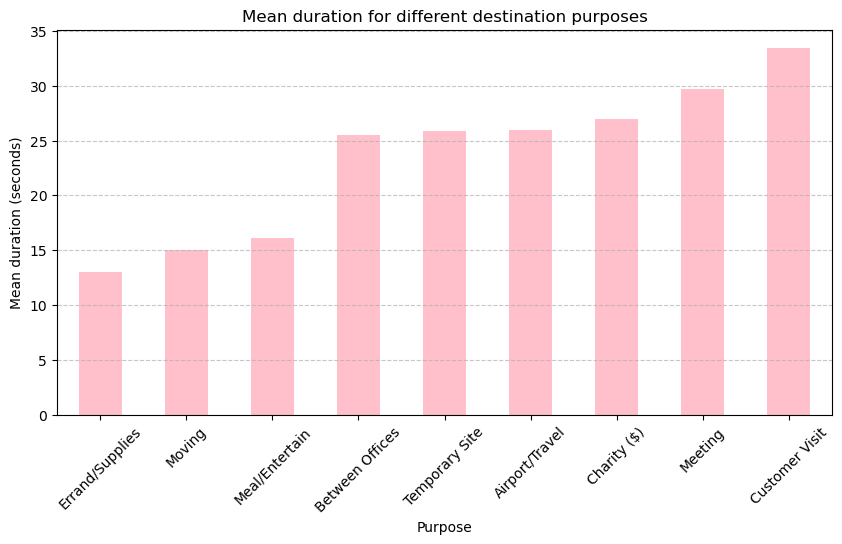

In [35]:
mean_durations_clean = mean_durations_clean.drop("Commute", errors="ignore")

plt.figure(figsize=(10, 5))
mean_durations_clean.sort_values().plot(kind="bar", color="pink")

# Opisy wykresu
plt.xlabel("Purpose")
plt.ylabel("Mean duration (seconds)")
plt.title("Mean duration for different destination purposes")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Wyświetlenie wykresu
plt.show()

## Skąd są najczęściej odjazdy i dokąd?

In [38]:
direction_start = df.groupby("START*")['START*'].count()
print(direction_start, "\n")

direction_stop = df.groupby("STOP*")['STOP*'].count()
print(direction_stop)

START*
Agnew               4
Almond              1
Apex               17
Arabi               1
Arlington           1
                   ..
West University     2
Weston              2
Westpark Place     17
Whitebridge        68
Winston Salem       1
Name: START*, Length: 177, dtype: int64 

STOP*
Agnew                  4
Alief                  1
Almond                 1
Apex                  17
Arabi                  1
                      ..
Weston                 5
Westpark Place        16
Whitebridge           65
Williamsburg Manor     1
Winston Salem          1
Name: STOP*, Length: 188, dtype: int64


In [40]:
sorted_values_start = direction_start.sort_values(ascending = False)
top10_start = sorted_values_start.head(10)
print(top10_start)

sorted_values_stop = direction_stop.sort_values(ascending = False)
top10_stop = sorted_values_stop.head(10)
print(top10_stop)

START*
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Durham               37
Lahore               36
Raleigh              28
Kar?chi              27
Apex                 17
Name: START*, dtype: int64
STOP*
Cary                203
Unknown Location    149
Morrisville          84
Whitebridge          65
Islamabad            58
Durham               36
Lahore               36
Raleigh              29
Kar?chi              26
Apex                 17
Name: STOP*, dtype: int64


<Figure size 1000x500 with 0 Axes>

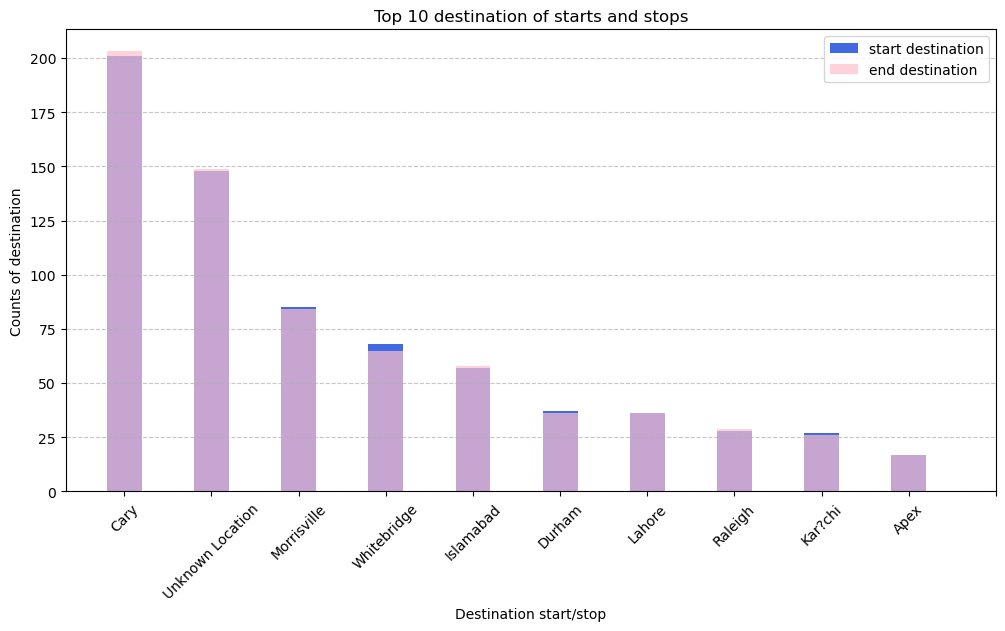

In [42]:
plt.figure(figsize=(10, 5))

plt.figure(figsize=(12, 6))
plt.bar(top10_start.index, top10_start.values, width= 0.4, color="royalblue", label= "start destination")
plt.bar(top10_stop.index, top10_stop.values, width = 0.4, color="pink", label = "end destination", alpha = 0.7)
plt.legend()
plt.xlabel("Destination start/stop")
plt.ylabel("Counts of destination")
plt.title("Top 10 destination of starts and stops")
plt.xticks(range(0, 11), rotation = 45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## Czy ilosc kursow jest powiązana z jakims swiętem?

START_DATE_ONLY
2016-12-29    13
2016-06-27    11
2016-12-19    11
2016-02-21    11
2016-03-04    10
2016-12-21    10
2016-02-19    10
2016-11-13    10
2016-08-26    10
2016-08-22    10
Name: count, dtype: int64

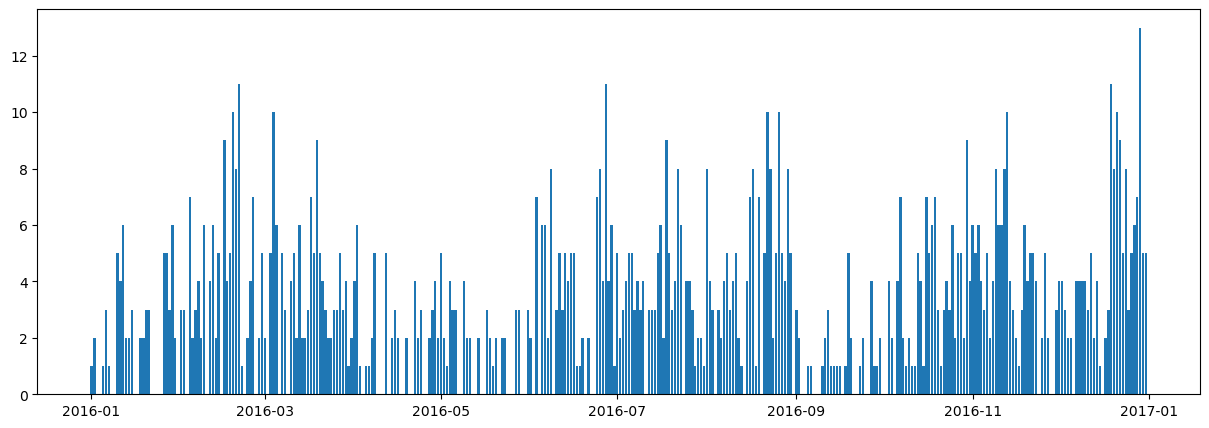

In [45]:
plt.figure(figsize=(15,5))
total_counts = df['START_DATE_ONLY'].value_counts().sort_index()
plt.bar(total_counts.index, total_counts.values)

total_counts.sort_values(ascending=False).head(10)


Zważając na nasz wynik możemy dojść do konkluzji, że ilość zamówionych przejazdów nie jest zależna od świąt. 

## Jak godziny szczytu mają wpływ na prędkość podróży

START_HOUR
0.0     22.411612
1.0     25.244878
2.0     51.503342
3.0     37.023379
5.0     38.083662
6.0     34.987447
7.0     27.702062
8.0     28.946191
9.0     25.704911
10.0    32.636946
11.0    21.541927
12.0    37.965568
13.0    24.220455
14.0    21.363466
15.0    22.868062
16.0    21.250707
17.0    27.746767
18.0    30.849548
19.0    25.319700
20.0    26.309878
21.0    31.810132
22.0    25.849632
23.0    30.054946
Name: VELOCITY, dtype: float64


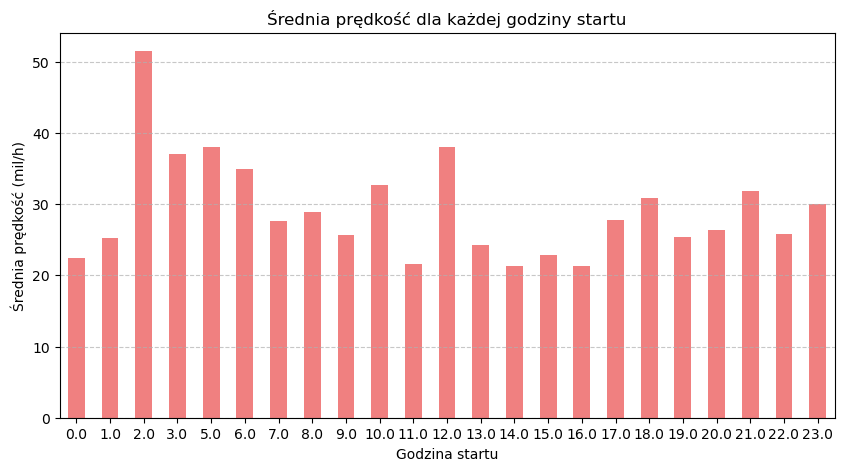

In [56]:
#dodanie kolumny prędkość do każdego wiersza
# s = v*t
# Konwersja na godziny
df["TIME_HOURS"] = df["DURATION"].dt.total_seconds() / 3600  
df.loc[df["TIME_HOURS"] == 0, "TIME_HOURS"] = np.nan  
# v = s/t
df["VELOCITY"] = df["MILES*"] / df["TIME_HOURS"]

df["START_HOUR"] = df["START_TIME_ONLY"].apply(lambda x: x.hour)
mean_velocity_by_hour = df.groupby("START_HOUR")["VELOCITY"].mean()
print(mean_velocity_by_hour)

plt.figure(figsize=(10, 5))
mean_velocity_by_hour.plot(kind="bar", color="lightcoral")

plt.xlabel("Godzina startu")
plt.ylabel("Średnia prędkość (mil/h)")
plt.title("Średnia prędkość dla każdej godziny startu")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Wyświetlenie wykresu
plt.show()


In [ ]:
Duże wartości prędkości są widoczne na naszym wykresie jedynie nad ranem. W godzinach szczytu prędkość aut jest nieznacznie mniejsza niż w pozostałych godzinach . Wpływ na to mogą mieć korki, duże natężenie innych pojazdów na ulicy itp.